In [1]:
import sys, os, pickle
print(sys.version)
import numpy as np
import pandas as pd
import scipy.sparse as sparse
import matplotlib.pyplot as plt
from datetime import datetime

import warnings
warnings.filterwarnings("error", category=RuntimeWarning)

3.9.13 (tags/v3.9.13:6de2ca5, May 17 2022, 16:36:42) [MSC v.1929 64 bit (AMD64)]


In [2]:
train = pd.read_csv(os.path.join("data", "sign_mnist_train.csv"))
valid = pd.read_csv(os.path.join("data", "sign_mnist_test.csv"))
print(train.shape, valid.shape)
train.head()

(27455, 785) (7172, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [3]:
y_col = "label"
X = (
    train
    .drop(y_col, axis=1)
    .to_numpy()
    .astype(np.int16) # Downcast to save memory 
)
y = train[y_col].to_numpy().astype(np.int8)

def one_hot(data, uniques=None):
    if uniques is None:
        uniques = np.unique(data)
    _data = np.squeeze(data)[:, np.newaxis] # Enforce as column vector
    _labels = np.squeeze(uniques)[np.newaxis] # Enforce as row vector
    return _data == _labels    

possible_labels = np.unique(y)
Y = one_hot(y, possible_labels)
print(X.shape, Y.shape)
del train

(27455, 784) (27455, 24)


In [4]:
X_valid = (
    valid
    .drop(y_col, axis=1)
    .to_numpy()
    .astype(np.int16) # Downcast to save memory 
)
y_valid = valid[y_col].to_numpy().astype(np.int8)
print(X_valid.shape, y_valid.shape)
y_valid[:10]

(7172, 784) (7172,)


array([ 6,  5, 10,  0,  3, 21, 10, 14,  3,  7], dtype=int8)

In [5]:
subset = y <= 2
X_ = X[subset]
Y_ = Y[subset, :3]
toy_labels = [0, 1, 2]
print(X_.shape, Y_.shape)

(3280, 784) (3280, 3)


C:\Users\archi\AppData\Local\Temp\ipykernel_15372\1939488016.py:1: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  samples = np.array([


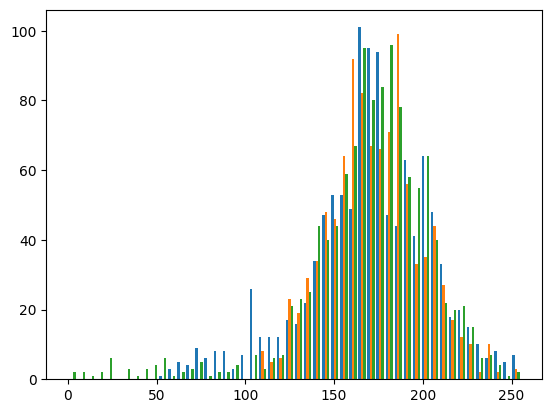

In [6]:
samples = np.array([
    X_[y[subset]==label, 250]
    for label in [0, 1, 2]
])
plt.hist(samples.T, bins=50)
plt.show()

In [7]:
def entropy(freqs, eps=1e-10):
    _sums = np.sum(freqs, axis=-1, keepdims=True)
    p = np.array(freqs) / np.maximum(_sums, eps)
    return -1. * np.sum(
        p * np.log2(np.maximum(p, eps)),
        axis = -1
    )

def conditional_entropy(freqs):
    shares = np.sum(freqs, axis=-1, keepdims=True)
    _sums = np.sum(
        shares, 
        axis = -min(2, np.ndim(shares)),
        keepdims=True
    )
    shares = shares / _sums
    entropies = entropy(freqs)
    if np.ndim(shares) > 2:
        cond_entr = [
            entr.dot(s)
            for entr, s in zip(entropies, shares)
        ]
    else:
        cond_entr = np.dot(entropies, shares)
    return np.squeeze(cond_entr)

In [8]:
a = [20, 10]
b = [10, 0]
c = [15, 7]
d = [15, 3]
print(entropy(a))
print(entropy(b))
print(entropy([a, b]))
print(entropy([
    [a, b],
    [c, d]
]))

print(conditional_entropy([a, b]))
print(conditional_entropy([c, d]))
print(conditional_entropy([
    [a, b],
    [c, d],
    [a, b],
    [c, d]
]))

0.9182958340544896
-0.0
[ 0.91829583 -0.        ]
[[ 0.91829583 -0.        ]
 [ 0.90239328  0.65002242]]
0.6887218755408672
0.7888263952789978
[0.68872188 0.7888264  0.68872188 0.7888264 ]


## Decision tree implementation

In [9]:
SPLITS_TO_TEST = np.arange(X.min().min(), X.max().max()) + 0.5
SPLITS_TO_TEST[[0, -1]]

array([  0.5, 254.5])

In [10]:
class TreeClassifier():

    def __init__(self, 
                 classes: np.ndarray,
                 max_depth: int = 1,
                 min_samples_per_leaf: int = 1):
        self.classes = classes
        self.max_depth = max_depth
        self.min_samples_per_leaf = min_samples_per_leaf

    def get_split_result(self, x_vec, boundary, y_matrix):
        test = x_vec <= boundary
        return np.array([
            y_matrix[test].sum(0),
            y_matrix[~test].sum(0)
        ])
        
    def single_feature_best_split(self, 
                                  x_vec, 
                                  y_matrix,
                                  splits = SPLITS_TO_TEST,
                                  return_entropies: bool = False,
                                  **kwargs):
        _splits = np.array([
            self.get_split_result(x_vec, s, y_matrix)
            for s in splits
        ])
        conditional_entropies = conditional_entropy(_splits)
        argmin = np.argmin(conditional_entropies)
        best = splits[argmin]
        if return_entropies:
            return argmin, best, conditional_entropies
        else:
            return argmin, best
        
    def all_features_best_split(self, 
                                X, 
                                y_matrix,
                                splits = SPLITS_TO_TEST,
                                return_entropies: bool = False,
                                **kwargs):
        d = X.shape[1]
        argmins = np.inf * np.ones(d)
        entropies = -1. * np.ones((d, len(splits)))
        for i in range(d):
            argmins[i], _, entropies[i] = self.single_feature_best_split(
                x_vec = X[:, i],
                y_matrix = y_matrix,
                splits = splits,
                return_entropies = True
            )
        argmins = argmins.astype(int)
        min_entropies = entropies[np.arange(d), argmins]
        feature_to_use = np.argmin(min_entropies)
        boundary_to_use = splits[argmins[feature_to_use]]
        if return_entropies:
            return feature_to_use, boundary_to_use, entropies
        else:
            return feature_to_use, boundary_to_use

    def fit(self, X, y_matrix, **kwargs):
        self.branches = None
        self.frequencies = y_matrix.sum(0)
        if self.max_depth > 0:
            n = X.shape[0]
            if n > (threshold := self.min_samples_per_leaf):
                self.feature, self.boundary = self.all_features_best_split(
                    X = X,
                    y_matrix = y_matrix,
                    **kwargs
                )
                test = X[:, self.feature] <= self.boundary
                sufficient = lambda arr: arr.sum() >= threshold
                if sufficient(test) and sufficient(~test):
                    self.branches = []
                    for subset in [~test, test]:
                        branch = TreeClassifier(
                            classes = self.classes,
                            max_depth = self.max_depth - 1,
                            min_samples_per_leaf = self.min_samples_per_leaf
                        )
                        branch.fit(X[subset], y_matrix[subset], **kwargs)
                        self.branches.append(branch)

    def predict_proba(self, X, **kwargs):
        if np.ndim(X) == 1:
            X = X[np.newaxis] # Enforce row-vector format
        n = X.shape[0]
        if self.branches is None:
            freqs = self.frequencies / self.frequencies.sum()
            probs = np.array([freqs for _ in range(n)])
        else:
            probs = -1. * np.ones((n, len(self.classes)))
            above_threshold = X[:, self.feature] <= self.boundary
            for case, branch in enumerate(self.branches):
                select = above_threshold == case
                if sum(select) > 0:
                    probs[select] = branch.predict_proba(X[select], **kwargs)
            assert np.all(probs >= 0), f"predict_proba failed!"
        return probs
    
    def predict(self, X, **kwargs):
        probs = self.predict_proba(X, **kwargs)
        return self.classes[np.argmax(probs, axis=-1).astype(int)]


tree = TreeClassifier(
    classes = np.array(toy_labels),
    max_depth = 3
)
toy_X = X_[:, :20]
#tree.fit(toy_X, Y_)
#preds = tree.predict(toy_X)
#preds

In [11]:
test_x_vec = X_[:, 0]
print(tree.get_split_result(
    x_vec = test_x_vec,
    boundary = 221.5,
    y_matrix = Y_
))

[[1088 1002 1106]
 [  38    8   38]]


Best split: 182.5


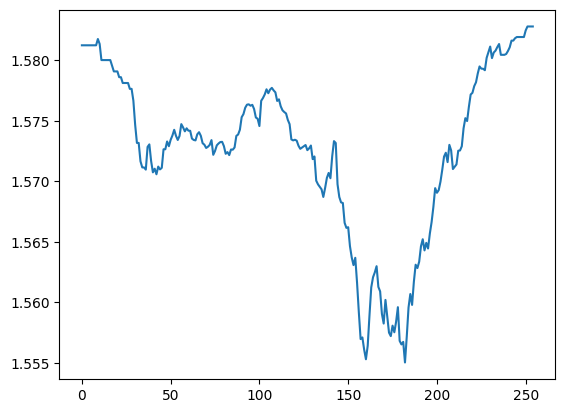

In [12]:
_, best, cond_entr = tree.single_feature_best_split(
    x_vec = test_x_vec,
    y_matrix = Y_,
    return_entropies = True
)
print(f"Best split: {best}")
plt.plot(cond_entr)
plt.show()

In [13]:
feature_to_use, boundary_to_use = tree.all_features_best_split(
    X = X_[:, :200],
    y_matrix = Y_
)
feature_to_use, boundary_to_use

(183, 94.5)

## Random Forest implementation

In [14]:
class RandomForestClassifier():

    def __init__(self,
                 classes: np.ndarray,
                 n_trees: int = 10,
                 share_obs: float = .2,
                 share_features: float = .2,
                 *args, **kwargs):
        self.classes = classes
        assert 0 < share_obs <= 1
        self.share_obs = share_obs
        assert 0 < share_features <= 1
        self.share_features = share_features
        self.n_trees = n_trees
        self.tree_args = kwargs
        self.trees = [
            TreeClassifier(classes=classes, **kwargs)
            for _ in range(n_trees)
        ]
        self.features = [None for _ in range(n_trees)]

    def bootstrap_dims(self, n, d):        
        sample_size = int(round(max(1, n * self.share_obs)))
        n_features = int(round(max(1, d * self.share_features)))
        return sample_size, n_features

    def fit_single_tree(self,
                        X, y_matrix, 
                        index,
                        sample_size: int = None,
                        n_features: int = None,
                        replace: bool = True,
                        **kwargs):
        n, d = X.shape
        if sample_size is None or n_features is None:
            sample_size, n_features = self.bootstrap_dims(n, d)
        obs_idx = np.random.choice(
            range(n), 
            sample_size, 
            replace=replace
        )
        feature_idx = np.random.choice(
            range(d), 
            n_features, 
            replace=False
        )
        self.features[index] = feature_idx
        self.trees[index].fit(
            X = X[obs_idx][:, feature_idx],
            y_matrix = y_matrix[obs_idx],
            **kwargs
        )

    def fit(self, 
            X, y_matrix, 
            verbose: bool = False,
            **kwargs):
        sample_size, n_features = self.bootstrap_dims(*X.shape)
        for i in range(self.n_trees):
            if verbose:
                print(f"Fitting tree {i+1} / {self.n_trees}", end="\r")
            self.fit_single_tree(
                X, y_matrix, 
                index = i,
                sample_size = sample_size, 
                n_features = n_features,
                **kwargs
            )
        if verbose: print("")
    
    def add_tree(self, *args, **kwargs):
        self.n_trees += 1
        self.features.append(None)
        self.trees.append(TreeClassifier(
            classes = self.classes, 
            **self.tree_args
        ))
        self.fit_single_tree(*args, index=-1, **kwargs)

    def predict_proba(self, X, **kwargs):
        probs = np.array([
            tree.predict_proba(X[:, features], **kwargs)
            for tree, features in zip(self.trees, self.features)
        ])
        sum_probs = np.sum(probs, axis=0)
        avg_probs = sum_probs / np.sum(sum_probs, axis=-1, keepdims=True)
        return avg_probs
    
    def predict(self, X,
                first_past_the_post: bool = True,
                **kwargs):
        if first_past_the_post:
            tree_preds = np.sum([
                one_hot(
                    tree.predict(X[:, features], **kwargs),
                    self.classes
                ) for tree, features in zip(self.trees, self.features)
            ], axis=0)
        else:
            tree_preds = self.predict_proba(X, **kwargs)
        preds = self.classes[np.argmax(tree_preds, axis=-1)]
        return preds
    

rf = RandomForestClassifier(
    classes = np.array(toy_labels),
    max_depth = 2,
    share_obs = .5,
    share_features = .5,
    n_trees = 5
)
print(toy_X.shape, toy_X[:10].shape)
rf.fit(toy_X, Y_, verbose=True)
hard_preds = rf.predict(toy_X[:10])
prob_preds = rf.predict(toy_X[:10], first_past_the_post=False)
print(hard_preds.shape, hard_preds)
print(prob_preds.shape, prob_preds)

(3280, 20) (10, 20)
Fitting tree 5 / 5
(10,) [2 0 2 2 2 2 2 0 0 2]
(10,) [2 0 2 2 2 2 2 0 0 2]


In [15]:
rf.add_tree(toy_X, Y_)
rf.predict(toy_X[:10])

array([2, 0, 2, 2, 2, 2, 2, 0, 0, 2])

In [16]:
probs = rf.predict_proba(toy_X)
print(np.mean(probs.sum(1) == 1))
print(max(np.absolute(probs.sum(1) - 1)))
print(probs.shape)
probs[:5]

0.9975609756097561
2.220446049250313e-16
(3280, 3)


array([[0.29206918, 0.32514922, 0.38278161],
       [0.45549997, 0.21728678, 0.32721325],
       [0.29206918, 0.32514922, 0.38278161],
       [0.29206918, 0.32514922, 0.38278161],
       [0.29206918, 0.32514922, 0.38278161]])

In [18]:
toy_rf = RandomForestClassifier(
    classes = np.array(toy_labels),
    max_depth = 2,
    share_obs = .2,
    share_features = .3,
    n_trees = 10
)
#toy_rf.fit(X_, Y_, verbose=True)

In [19]:
def check_accuracy(model, 
                   X_valid,
                   labels_valid,
                   approaches={
                       "Single-vote": True,
                       "Probabilistic-combination": False
                   },
                   verbose: bool = True,
                   **kwargs):
    accs = []
    for _type, fptp in approaches.items():
        preds = model.predict(
            X_valid, 
            first_past_the_post=fptp, 
            **kwargs
        )
        description = f"{_type} accuracy:"
        accs.append(acc := np.mean(preds == labels_valid))
        if verbose:
            print(f"{description.ljust(36)}{acc}")
    return accs

#check_accuracy(
#    model = toy_rf,
#    X = X_,
#    labels = y[subset],
#    verbose=False
#)

In [34]:
def evaluation_learning(fitting_args,
                        eval_args,
                        hyperparams,
                        tree_increment,
                        n_increments,
                        verbose: bool = True):
    rf = RandomForestClassifier(
        **hyperparams,
        n_trees = tree_increment
    )
    rf.fit(**fitting_args, verbose=verbose)
    learning = np.zeros((n_increments, 2))
    acc_args = {"model": rf, "verbose": False, **eval_args}
    learning[0] = (acc := check_accuracy(**acc_args))
    if verbose:
        print(f"Initial forest accuracy: {acc}")
    total = n_increments * tree_increment
    for i in range(1, n_increments):
        for j in range(tree_increment):
            if verbose:
                n_trees = i * tree_increment + j + 1
                print(f"{n_trees} / {total}", end="\r")
            rf.add_tree(**fitting_args, verbose=False)
        learning[i] = (acc := check_accuracy(**acc_args))
        if verbose:
            print(f"Accuracy with {n_trees} trees: {acc}")
    learning_df = pd.DataFrame(
        learning, 
        columns=["Voting", "Probabilistic"]
    )
    ti = tree_increment
    learning_df.index = np.arange(ti, total + ti, ti)
    learning_df.index.name = "Trees"
    return rf, learning_df

fitting_args = {
    "X": X,
    "y_matrix": Y,
    #"verbose": False,
    #"labels": y
}
eval_args = {
    "X_valid": X_valid,
    "labels_valid": y_valid
}
hyperparams = {    
    "classes": possible_labels,
    "max_depth": 3,
    "share_obs": .2,
    "share_features": .3
}

In [22]:
def plot_learning(learning_df):
    for col in learning_df:
        plt.plot(learning_df[col], label=col)
    plt.legend()
    plt.xlabel("Number of trees")
    plt.ylabel("Accuracy")
    plt.show()

#plot_learning(learning_df)

In [35]:
forests = {}
learning_dfs = {}
for depth in range(2, 9):
    print(f"\n\nTesting for max_depth=={depth}")
    print(f"Started at: {datetime.now()}")
    hyperparams["max_depth"] = depth
    rf, learning_df = evaluation_learning(
        fitting_args = fitting_args,
        eval_args = eval_args,
        hyperparams = hyperparams,
        tree_increment = 10,
        n_increments = 5
    )
    with open(f"trained_rf_depth{depth}.pkl", "wb") as f:
        pickle.dump(rf, f)
    forests[depth], learning_dfs[depth] = rf, learning_df
    print(learning_df)



Testing for max_depth==2
Started at: 2023-12-03 13:00:23.328164
Fitting tree 10 / 10
Initial forest accuracy: [0.1003904071388734, 0.14389291689905187]
Accuracy with 20 trees: [0.10805911879531511, 0.15783602900167318]
Accuracy with 30 trees: [0.1228388176240937, 0.15672058003346348]
Accuracy with 40 trees: [0.1249302844394869, 0.160345789180145]
Accuracy with 50 trees: [0.1238148354712772, 0.15992749581706636]
         Voting  Probabilistic
Trees                         
10     0.100390       0.143893
20     0.108059       0.157836
30     0.122839       0.156721
40     0.124930       0.160346
50     0.123815       0.159927


Testing for max_depth==3
Started at: 2023-12-03 13:26:25.906204
Fitting tree 10 / 10
Initial forest accuracy: [0.19060234244283325, 0.23117679866146124]
Accuracy with 20 trees: [0.1857222532069158, 0.2373117679866146]
Accuracy with 30 trees: [0.19492470719464586, 0.24316787506971557]
Accuracy with 40 trees: [0.19520356943669828, 0.23229224762967093]
Accuracy wit

In [36]:
for depth in range(9, 11):
    print(f"\n\nTesting for max_depth=={depth}")
    print(f"Started at: {datetime.now()}")
    hyperparams["max_depth"] = depth
    rf, learning_df = evaluation_learning(
        fitting_args = fitting_args,
        eval_args = eval_args,
        hyperparams = hyperparams,
        tree_increment = 10,
        n_increments = 5
    )
    with open(f"trained_rf_depth{depth}.pkl", "wb") as f:
        pickle.dump(rf, f)
    forests[depth], learning_dfs[depth] = rf, learning_df
    print(learning_df)



Testing for max_depth==9
Started at: 2023-12-04 01:07:35.919114
Fitting tree 10 / 10
Initial forest accuracy: [0.5663692136084774, 0.5907696597880647]
Accuracy with 20 trees: [0.6378973786949247, 0.6639709983268266]
Accuracy with 30 trees: [0.6611823759063022, 0.6841885108756275]
Accuracy with 40 trees: [0.6844673731176799, 0.7063580591187953]
Accuracy with 50 trees: [0.6846068042387061, 0.7066369213608478]
         Voting  Probabilistic
Trees                         
10     0.566369       0.590770
20     0.637897       0.663971
30     0.661182       0.684189
40     0.684467       0.706358
50     0.684607       0.706637


Testing for max_depth==10
Started at: 2023-12-04 07:17:47.248118
Fitting tree 10 / 10
Initial forest accuracy: [0.5932794199665365, 0.6017847183491355]
Accuracy with 20 trees: [0.6597880646960401, 0.6730340211935304]
Accuracy with 30 trees: [0.6853039598438372, 0.6953430005577245]
Accuracy with 40 trees: [0.6952035694366983, 0.7119353039598438]
Accuracy with 50 tree

In [37]:
best_val_accs = pd.Series(
    [df.Probabilistic.max() for df in learning_dfs.values()],
    index = learning_dfs.keys(),
    name = "Best accuracies"
)

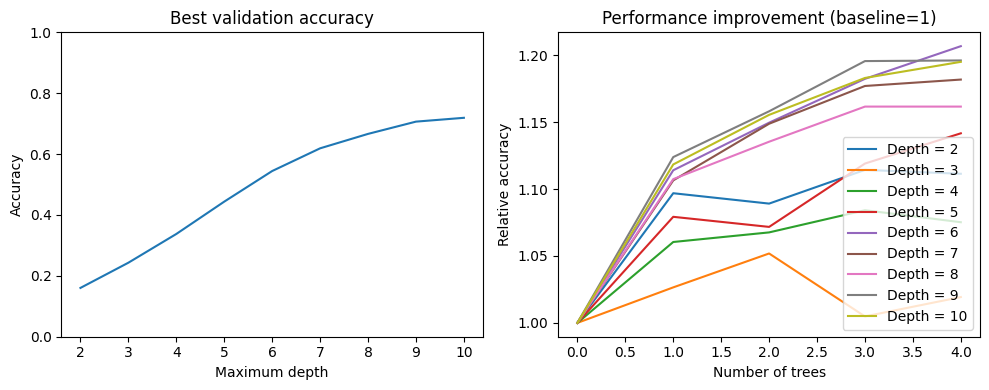

In [38]:
axes = plt.subplots(ncols=2, figsize=(10, 4))[1]
axes[0].plot(best_val_accs)
axes[0].set_title("Best validation accuracy")
axes[0].set_xlabel("Maximum depth")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim([0,1])
for depth, acc_df in learning_dfs.items():
    x = acc_df.Probabilistic.to_numpy()
    axes[1].plot(x / x[0], label=f"Depth = {depth}")
axes[1].legend()
axes[1].set_title("Performance improvement (baseline=1)")
axes[1].set_xlabel("Number of trees")
axes[1].set_ylabel("Relative accuracy")
plt.tight_layout()
plt.show()

In [39]:
test = pd.read_csv(os.path.join(
    "data", 
    "ascii-sign-language",
    "test.csv"),
    index_col = 0)
print(test.shape)
test.head()

(3000, 1568)


,pixel_a1,pixel_a2,pixel_a3,pixel_a4,pixel_a5,pixel_a6,pixel_a7,pixel_a8,pixel_a9,pixel_a10,...,pixel_b775,pixel_b776,pixel_b777,pixel_b778,pixel_b779,pixel_b780,pixel_b781,pixel_b782,pixel_b783,pixel_b784
id,,,,,,,,,,,,,,,,,,,,,
0,225,227,227,228,229,229,227,227,227,227,...,163,164,164,162,163,162,162,161,161,158
1,190,191,190,191,190,190,192,192,191,192,...,110,89,82,86,134,186,188,190,190,191
2,195,195,197,196,197,198,199,197,199,198,...,129,122,122,122,121,121,117,124,202,243
3,186,188,191,192,192,194,195,197,199,198,...,199,199,199,198,196,196,195,194,192,192
4,32,68,69,73,79,84,92,102,110,113,...,214,232,229,228,228,227,225,223,221,220


In [40]:
d = int(test.shape[1] / 2)
test_sets = np.array([
    test.iloc[:, :d].to_numpy(),
    test.iloc[:, d:].to_numpy()
])
print(test_sets.shape)
ascii_values = np.array([
    rf.predict(
        X = ts,
        first_past_the_post = False
    ) for ts in test_sets
])
print(ascii_values.shape)

(2, 3000, 784)
(2, 3000)


In [41]:
preds = ascii_values.sum(0)

In [42]:
from functions import convert_predictions_to_chars

In [43]:
def convert_to_char(ascii_sum):
    if ascii_sum > 122:
        return chr(ascii_sum - 65)
    return chr(ascii_sum)

rf_preds_to_submit = pd.Series(
    convert_predictions_to_chars(preds),
    index = test.index,
    name = "label"
)
rf_preds_to_submit.head()

id
0    X
1    Y
2    G
3    \
4    \
Name: label, dtype: object

In [44]:
rf_preds_to_submit.unique()

array(['X', 'Y', 'G', '\\', 'g', '`', 'F', 'T', 'b', 'I', 'L', 'A', 'U',
       'Z', '_', 'V', 'Q', 'j', 'H', 'W', 'q', ']', '^', 'D', '[', 'c',
       'C', 'J', 'P', 'R', 'N', 'i', 'B', 'M', 'E', 'k', 'a', 'O', 'K',
       'm', 'o', 'f', 'd', 'S', 'l', 'e', 'n', 'h', 'p'], dtype=object)

In [45]:
rf_preds_to_submit.to_csv(
    "rf_preds.csv",
    index=True
)

In [ ]:
np.sqrt(d)

28.0